Project 1: Stock Market Trend Analyzer with SQL and Pandas
Description: Analyze historical stock prices using SQL and Pandas.
Dataset: https://finance.yahoo.com/
Tools: Pandas, NumPy, MySQL, Matplotlib, Seaborn
Database Schema: stocks(id, ticker, date, open, close, high, low, volume)
Output: Trend lines, moving averages, volatility visualization.


In [173]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd 
import mysql.connector
from scipy.stats import chi2_contingency
from datetime import date, timedelta


In [70]:
tickers=["AAPL","MSFT","TSLA","GOOG","RELIANCE.NS","TCS.NS","INFY.NS"]

In [71]:
start_date = date.today() - timedelta(days=365)
end_date = date.today()
all_data=[]

for ticker_name in tickers:
    df = yf.download(ticker_name, start=start_date, end=end_date)

    if df.empty:
        continue

    df = df.reset_index()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    df["Ticker"] = ticker_name

    df = df[["Date", "Ticker", "Open", "Close", "High", "Low", "Volume"]]

    all_data.append(df)

final_df = pd.concat(all_data, ignore_index=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [72]:
print(final_df)

           Date   Ticker         Open        Close         High          Low  \
0    2025-04-11     AAPL   185.292419   197.290115   198.674083   185.252584   
1    2025-04-14     AAPL   210.522464   201.641174   212.015955   200.287075   
2    2025-04-15     AAPL   200.984034   201.262817   202.626867   198.932975   
3    2025-04-16     AAPL   197.499204   193.426956   199.829045   191.535192   
4    2025-04-17     AAPL   196.344245   196.125198   197.967176   193.576310   
...         ...      ...          ...          ...          ...          ...   
1736 2026-04-06  INFY.NS  1301.400024  1306.199951  1320.000000  1299.000000   
1737 2026-04-07  INFY.NS  1302.000000  1339.400024  1345.099976  1293.500000   
1738 2026-04-08  INFY.NS  1349.000000  1346.199951  1376.900024  1331.000000   
1739 2026-04-09  INFY.NS  1329.900024  1331.599976  1337.500000  1314.000000   
1740 2026-04-10  INFY.NS  1318.000000  1292.500000  1318.900024  1283.300049   

         Volume  
0      87435900  
1  

In [150]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="stock"
)

cursor=conn.cursor()


In [74]:
# insert_query = '''
# INSERT INTO stocks (Date, Ticker, Open, Close, High, Low, Volume)
# VALUES (%s, %s, %s, %s, %s, %s, %s)
# '''

# for _, row in final_df.iterrows():
#     values = (
#         row["Date"].date(),
#         row["Ticker"],
#         float(row["Open"]),
#         float(row["Close"]),
#         float(row["High"]),
#         float(row["Low"]),
#         int(row["Volume"])
#     )
#     cursor.execute(insert_query, values)

# conn.commit()
# print("Multi-stock data inserted successfully!")

# cursor.close()
# conn.close()

Category wise analysis

In [75]:
cursor.execute('''
    SELECT ticker, COUNT(*) AS cnt
    FROM stocks
    GROUP BY ticker
    ORDER BY cnt DESC
''')

rows = cursor.fetchall()

for row in rows:
    print(row)

('TSLA', 250)
('AAPL', 250)
('GOOG', 250)
('MSFT', 250)
('RELIANCE.NS', 247)
('TCS.NS', 247)
('INFY.NS', 247)


2) Top performing stock

In [ ]:
cursor.execute('''
               SELECT ticker, (MAX(close))-(MIN(close)) AS growth
               FROM stocks
               GROUP BY ticker
               ORDER BY growth DESC
               ''')

rows = cursor.fetchall()


for row in rows:
    row=list(row)
    row[1]=int(row[])
    print(tuple(row))

('TCS.NS', 1143)
('INFY.NS', 469)
('RELIANCE.NS', 378)
('TSLA', 262)
('GOOG', 195)
('MSFT', 183)
('AAPL', 93)


Average volume per stock

In [77]:
cursor.execute('''
               SELECT ticker,AVG(volume)
               FROM stocks
               GROUP BY ticker
               ''')

rows = cursor.fetchall()
for row in rows:
    row=list(row)
    row[1] = round(float(row[1]), 2)
    print(tuple(row))

('AAPL', 50676883.2)
('GOOG', 23584995.2)
('INFY.NS', 9035996.7)
('MSFT', 25136673.2)
('RELIANCE.NS', 12079639.89)
('TCS.NS', 3053551.8)
('TSLA', 85708286.4)


Ticker-wise Monthly Revenue Calculation

In [78]:
cursor.execute('''
    SELECT 
        ticker,
        DATE_FORMAT(Date,'%Y-%m') AS month,
        SUM(close) AS monthly_revenue
    FROM stocks
    GROUP BY ticker, month
    ORDER BY ticker, month
''')

rows = cursor.fetchall()

for row in rows:
    row=list(row)
    row[2]=round(float(row[2]),2)
    print(tuple(row))

('AAPL', '2025-04', 2631.59)
('AAPL', '2025-05', 4268.06)
('AAPL', '2025-06', 4000.97)
('AAPL', '2025-07', 4634.09)
('AAPL', '2025-08', 4707.17)
('AAPL', '2025-09', 5082.52)
('AAPL', '2025-10', 5929.5)
('AAPL', '2025-11', 5155.35)
('AAPL', '2025-12', 6073.05)
('AAPL', '2026-01', 5148.2)
('AAPL', '2026-02', 5113.11)
('AAPL', '2026-03', 5607.94)
('AAPL', '2026-04', 1803.78)
('GOOG', '2025-04', 2053.47)
('GOOG', '2025-05', 3468.88)
('GOOG', '2025-06', 3464.85)
('GOOG', '2025-07', 4080.95)
('GOOG', '2025-08', 4250.81)
('GOOG', '2025-09', 5094.31)
('GOOG', '2025-10', 5854.9)
('GOOG', '2025-11', 5565.94)
('GOOG', '2025-12', 6891.62)
('GOOG', '2026-01', 6580.98)
('GOOG', '2026-02', 6018.33)
('GOOG', '2026-03', 6554.51)
('GOOG', '2026-04', 2137.78)
('INFY.NS', '2025-04', 16946.53)
('INFY.NS', '2025-05', 31797.97)
('INFY.NS', '2025-06', 33015.46)
('INFY.NS', '2025-07', 35827.32)
('INFY.NS', '2025-08', 27401.52)
('INFY.NS', '2025-09', 32326.81)
('INFY.NS', '2025-10', 30837.2)
('INFY.NS', '2025-1

Highest Monthly Revenue per Ticker

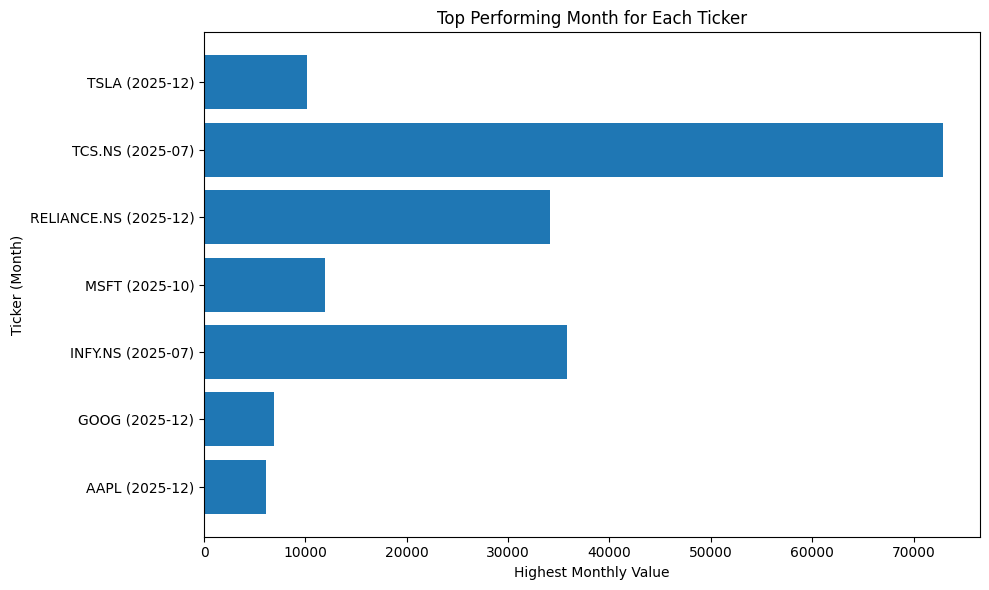

('AAPL', '2025-12', 6073.05)
('GOOG', '2025-12', 6891.62)
('INFY.NS', '2025-07', 35827.32)
('MSFT', '2025-10', 11938.02)
('RELIANCE.NS', '2025-12', 34109.9)
('TCS.NS', '2025-07', 72909.49)
('TSLA', '2025-12', 10153.39)


In [111]:
cursor.execute('''
    SELECT t1.ticker, t1.month, t1.monthly_value
    FROM (
        SELECT 
            ticker,
            DATE_FORMAT(Date,'%Y-%m') AS month,
            SUM(close) AS monthly_value
        FROM stocks
        GROUP BY ticker, month
    ) t1
    JOIN (
        SELECT ticker, MAX(monthly_value) AS max_val
        FROM (
            SELECT 
                ticker,
                DATE_FORMAT(Date,'%Y-%m') AS month,
                SUM(close) AS monthly_value
            FROM stocks
            GROUP BY ticker, month
        ) t2
        GROUP BY ticker
    ) t2
    ON t1.ticker = t2.ticker AND t1.monthly_value = t2.max_val
''')

rows = cursor.fetchall()

labels=[f"{row[0]} ({row[1]})" for row in rows]
values=[float(row[2]) for row in rows]

plt.figure(figsize=(10,6))

plt.barh(labels,values)
plt.xlabel("Highest Monthly Value")
plt.ylabel("Ticker (Month)")
plt.title("Top Performing Month for Each Ticker")
plt.tight_layout()
plt.show()


for row in rows:
    row=list(row)
    row[2]=round(float(row[2]),2)
    print(tuple(row))

Highest Monthly Revenue by Each Ticker

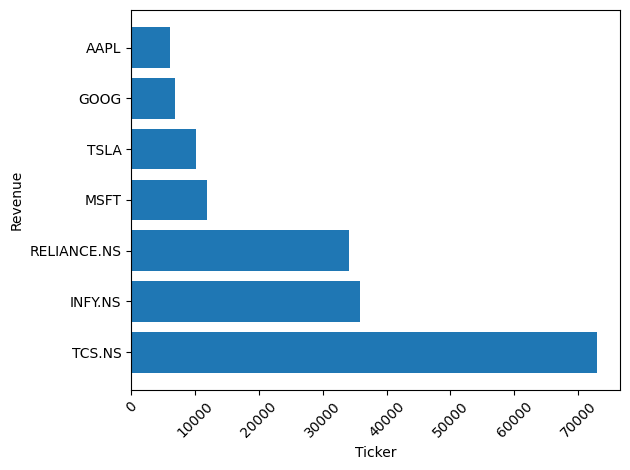

('TCS.NS', 72909.49)
('INFY.NS', 35827.32)
('RELIANCE.NS', 34109.9)
('MSFT', 11938.02)
('TSLA', 10153.39)
('GOOG', 6891.62)
('AAPL', 6073.05)


In [104]:
cursor.execute('''
    SELECT 
        ticker,
        MAX(monthly_value) AS highest_monthly_value
    FROM (
        SELECT 
            ticker,
            DATE_FORMAT(Date,'%Y-%m') AS month,
            SUM(close) AS monthly_value
        FROM stocks
        GROUP BY ticker, month
    ) AS sub
    GROUP BY ticker
    ORDER BY highest_monthly_value DESC
''')

tick=[row[0] for row in rows]
revenue=[row[1] for row in rows]


plt.Figure(figsize=(5,6))
plt.barh(tick,revenue)
plt.xlabel("Ticker")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



rows = cursor.fetchall()

for row in rows:
    row=list(row)
    row[1]=round(float(row[1]),2)
    print(tuple(row))

Most traded stocks (volume wise)

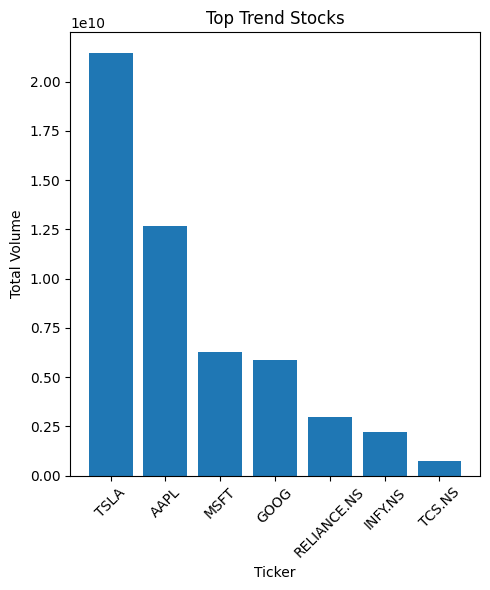

('TSLA', 21427071600)
('AAPL', 12669220800)
('MSFT', 6284168300)
('GOOG', 5896248800)
('RELIANCE.NS', 2983671052)
('INFY.NS', 2231891184)
('TCS.NS', 754227295)


In [107]:
cursor.execute('''
    SELECT ticker,
           SUM(volume) AS total_volume
    FROM stocks
    GROUP BY ticker
    ORDER BY total_volume DESC
    
''')
rows = cursor.fetchall()

ticker = [row[0] for row in rows]
volumes = [row[1] for row in rows]

plt.figure(figsize=(5,6))
plt.bar(ticker, volumes)

plt.xlabel("Ticker")
plt.ylabel("Total Volume")
plt.title("Top Trend Stocks")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for row in rows:
    row=list(row)
    row[1]=int(row[1])
    print(tuple(row))

In [115]:
df=pd.read_sql("select * from stocks",conn)
df.to_csv("stock_data.csv",index=False)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25832\4243447276.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql("select * from stocks",conn)


In [117]:
df=pd.read_csv("stock_data.csv")

In [118]:
df.head(10)

,id,Date,Ticker,Open,Close,High,Low,Volume
0,1,2025-04-11,AAPL,185.29,197.29,198.67,185.25,87435900
1,2,2025-04-14,AAPL,210.52,201.64,212.02,200.29,101352900
2,3,2025-04-15,AAPL,200.98,201.26,202.63,198.93,51343900
3,4,2025-04-16,AAPL,197.50,193.43,199.83,191.54,59732400
4,5,2025-04-17,AAPL,196.34,196.13,197.97,193.58,52164700
5,6,2025-04-21,AAPL,192.43,192.32,192.96,188.99,46742500
6,7,2025-04-22,AAPL,195.27,198.87,200.72,195.12,52976400
7,8,2025-04-23,AAPL,205.11,203.71,207.10,201.92,52929200
8,9,2025-04-24,AAPL,204.00,207.47,207.92,202.06,47311000
9,10,2025-04-25,AAPL,205.47,208.37,208.84,205.31,38222300


In [120]:
df.tail(10)

,id,Date,Ticker,Open,Close,High,Low,Volume
1731,1732,2026-03-25,INFY.NS,1270.0,1279.1,1290.6,1257.1,10824030
1732,1733,2026-03-27,INFY.NS,1285.2,1269.7,1294.8,1263.2,13092541
1733,1734,2026-03-30,INFY.NS,1250.0,1250.6,1265.5,1243.0,14108486
1734,1735,2026-04-01,INFY.NS,1290.0,1275.7,1303.0,1269.5,8137156
1735,1736,2026-04-02,INFY.NS,1260.0,1300.8,1305.4,1259.8,12873492
1736,1737,2026-04-06,INFY.NS,1301.4,1306.2,1320.0,1299.0,10208682
1737,1738,2026-04-07,INFY.NS,1302.0,1339.4,1345.1,1293.5,15355792
1738,1739,2026-04-08,INFY.NS,1349.0,1346.2,1376.9,1331.0,16030133
1739,1740,2026-04-09,INFY.NS,1329.9,1331.6,1337.5,1314.0,14894607
1740,1741,2026-04-10,INFY.NS,1318.0,1292.5,1318.9,1283.3,19233369


In [122]:
df.isnull().mean().mul(100)

id        0.0
Date      0.0
Ticker    0.0
Open      0.0
Close     0.0
High      0.0
Low       0.0
Volume    0.0
dtype: float64

In [126]:
df[df.duplicated()].shape[0]

0

In [127]:
null_col=df.columns[df.isnull().any()]

print(null_col)

Index([], dtype='str')


In [128]:
cate=df.select_dtypes(include=['object']).columns
print(cate)

Index(['Date', 'Ticker'], dtype='str')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25832\1255437345.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cate=df.select_dtypes(include=['object']).columns


In [131]:
nume=df.select_dtypes(include=np.number).columns
print(nume)

Index(['id', 'Open', 'Close', 'High', 'Low', 'Volume'], dtype='str')


In [132]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1741.0,8.710000e+02,5.027277e+02,1.00,436.00,871.00,1306.00,1.741000e+03
Open,1741.0,1.039725e+03,9.653565e+02,150.44,295.86,481.42,1491.07,3.499460e+03
Close,1741.0,1.038839e+03,9.637992e+02,149.34,295.88,481.20,1490.88,3.499460e+03
High,1741.0,1.048895e+03,9.719112e+02,150.54,303.37,486.72,1504.07,3.509220e+03
Low,1741.0,1.029366e+03,9.568357e+02,147.89,290.00,474.78,1480.83,3.427640e+03
Volume,1741.0,3.000948e+07,3.092091e+07,0.00,8035026.00,19216900.00,43238300.00,2.874998e+08


In [179]:
df["Date"]=pd.to_datetime(df["Date"],errors="coerce")

In [135]:
std=np.std(df["Volume"])
print(std)

30912027.489432137


In [142]:
df["price_range"] = df["High"] - df["Low"]
df.sort_values("price_range", ascending=False).head()
# print(df["price_range"])

,id,Date,Ticker,Open,Close,High,Low,Volume,price_range
1449,1450,2026-02-03,TCS.NS,3350.00,3225.30,3350.00,3186.30,4366060,163.70
1456,1457,2026-02-12,TCS.NS,2869.80,2750.10,2880.00,2740.00,10612156,140.00
1258,1259,2025-04-30,TCS.NS,3356.02,3338.33,3392.65,3253.56,2809332,139.09
1450,1451,2026-02-04,TCS.NS,3120.00,2999.10,3120.00,2986.00,10852595,134.00
1457,1458,2026-02-13,TCS.NS,2585.00,2692.20,2713.00,2585.00,11168735,128.00


In [143]:
df["return"] = df["Close"].pct_change()
df[df["return"].abs() > 0.2]   # 20% jump

,id,Date,Ticker,Open,Close,High,Low,Volume,price_range,return
250,251,2025-04-11,MSFT,377.75,385.50,387.09,376.01,23839200,11.08,0.479960
500,501,2025-04-11,TSLA,251.84,252.31,257.74,241.36,128948100,16.38,-0.319681
750,751,2025-04-11,GOOG,155.05,158.85,159.31,155.05,22582000,4.26,-0.544777
1000,1001,2025-04-11,RELIANCE.NS,1190.40,1214.10,1217.79,1190.40,11224242,27.39,2.845496
1247,1248,2025-04-11,TCS.NS,3179.66,3123.55,3188.75,3098.90,7108961,89.85,1.313398
1494,1495,2025-04-11,INFY.NS,1370.69,1368.94,1397.44,1356.89,12567440,40.55,-0.457695


In [147]:
df["Open_Close_Range"]=df["Open"]-df["Close"]
df

,id,Date,Ticker,Open,Close,High,Low,Volume,price_range,return,Open_Close_Range
0,1,2025-04-11,AAPL,185.29,197.29,198.67,185.25,87435900,13.42,NaN,-12.00
1,2,2025-04-14,AAPL,210.52,201.64,212.02,200.29,101352900,11.73,0.022049,8.88
2,3,2025-04-15,AAPL,200.98,201.26,202.63,198.93,51343900,3.70,-0.001885,-0.28
3,4,2025-04-16,AAPL,197.50,193.43,199.83,191.54,59732400,8.29,-0.038905,4.07
4,5,2025-04-17,AAPL,196.34,196.13,197.97,193.58,52164700,4.39,0.013959,0.21
...,...,...,...,...,...,...,...,...,...,...,...
1736,1737,2026-04-06,INFY.NS,1301.40,1306.20,1320.00,1299.00,10208682,21.00,0.004151,-4.80
1737,1738,2026-04-07,INFY.NS,1302.00,1339.40,1345.10,1293.50,15355792,51.60,0.025417,-37.40
1738,1739,2026-04-08,INFY.NS,1349.00,1346.20,1376.90,1331.00,16030133,45.90,0.005077,2.80
1739,1740,2026-04-09,INFY.NS,1329.90,1331.60,1337.50,1314.00,14894607,23.50,-0.010845,-1.70


In [148]:
df.rename(columns={"price_range":"Price_Range"},inplace=True)
df.rename(columns={"return":"Return"},inplace=True)

In [149]:
df

,id,Date,Ticker,Open,Close,High,Low,Volume,Price_Range,Return,Open_Close_Range
0,1,2025-04-11,AAPL,185.29,197.29,198.67,185.25,87435900,13.42,NaN,-12.00
1,2,2025-04-14,AAPL,210.52,201.64,212.02,200.29,101352900,11.73,0.022049,8.88
2,3,2025-04-15,AAPL,200.98,201.26,202.63,198.93,51343900,3.70,-0.001885,-0.28
3,4,2025-04-16,AAPL,197.50,193.43,199.83,191.54,59732400,8.29,-0.038905,4.07
4,5,2025-04-17,AAPL,196.34,196.13,197.97,193.58,52164700,4.39,0.013959,0.21
...,...,...,...,...,...,...,...,...,...,...,...
1736,1737,2026-04-06,INFY.NS,1301.40,1306.20,1320.00,1299.00,10208682,21.00,0.004151,-4.80
1737,1738,2026-04-07,INFY.NS,1302.00,1339.40,1345.10,1293.50,15355792,51.60,0.025417,-37.40
1738,1739,2026-04-08,INFY.NS,1349.00,1346.20,1376.90,1331.00,16030133,45.90,0.005077,2.80
1739,1740,2026-04-09,INFY.NS,1329.90,1331.60,1337.50,1314.00,14894607,23.50,-0.010845,-1.70


In [152]:
print(df["Return"].skew())

27.804740719964034


In [153]:
print(df["Return"].kurtosis())

945.6908562686637


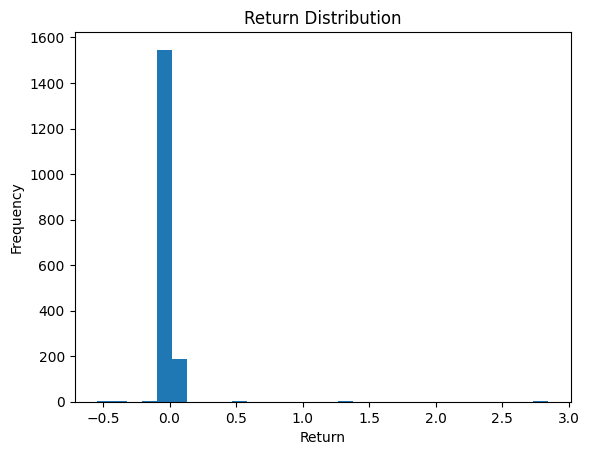

In [157]:
plt.hist(df["Return"].dropna(),bins=30)
plt.title("Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

In [159]:
df["Vol"]=np.where(df["Price_Range"]>df["Price_Range"].mean(),"High","Low")
df["Ret"]=np.where(df["Return"]>0,"Positive","Negative")
table=pd.crosstab(df["Vol"],df["Ret"])
chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(6.309508710538471), pvalue=np.float64(0.01200921127645522), dof=1, expected_freq=array([[303.41183228, 316.58816772],
       [548.58816772, 572.41183228]]))

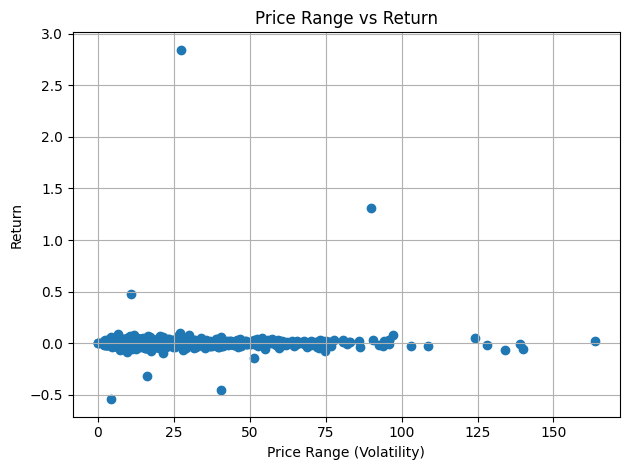

In [165]:
plt.Figure(figsize=(7,8))
plt.scatter(x=df["Price_Range"],y=df["Return"])
plt.xlabel("Price Range (Volatility)")
plt.ylabel("Return")
plt.title("Price Range vs Return")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # 2 month gap
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

Trend Line (Price trend)

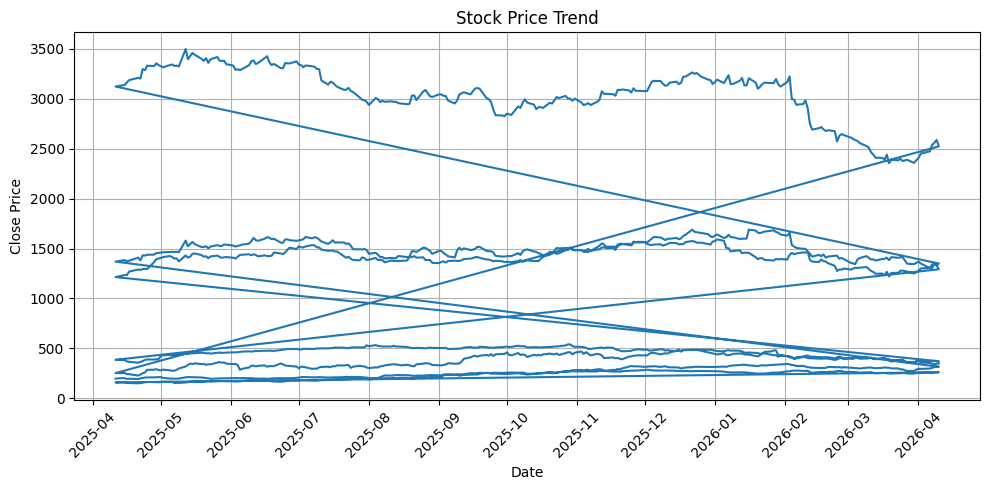

In [193]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"],df["Close"])

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel("Date")
plt.title("Stock Price Trend")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

Moving Averages

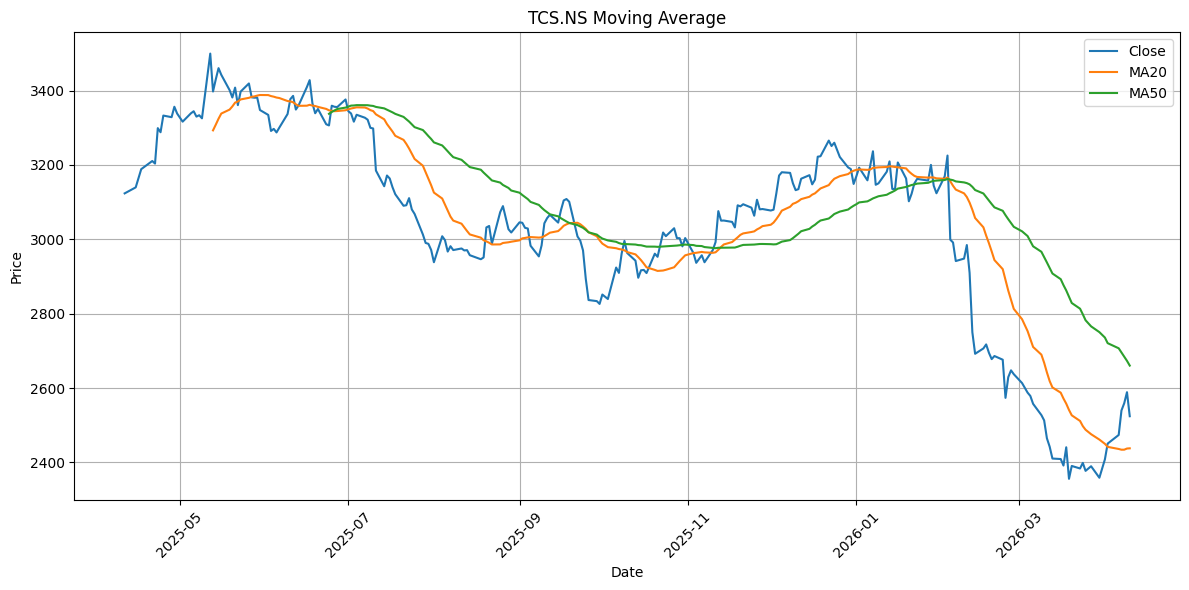

In [192]:
stock_df = df[df["Ticker"] == "TCS.NS"].copy()
stock_df = stock_df.sort_values("Date")

stock_df["MA20"] = stock_df["Close"].rolling(20).mean()
stock_df["MA50"] = stock_df["Close"].rolling(50).mean()

plt.figure(figsize=(12,6))
plt.plot(stock_df["Date"], stock_df["Close"], label="Close")
plt.plot(stock_df["Date"], stock_df["MA20"], label="MA20")
plt.plot(stock_df["Date"], stock_df["MA50"], label="MA50")

plt.title("TCS.NS Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Volatility Visualization

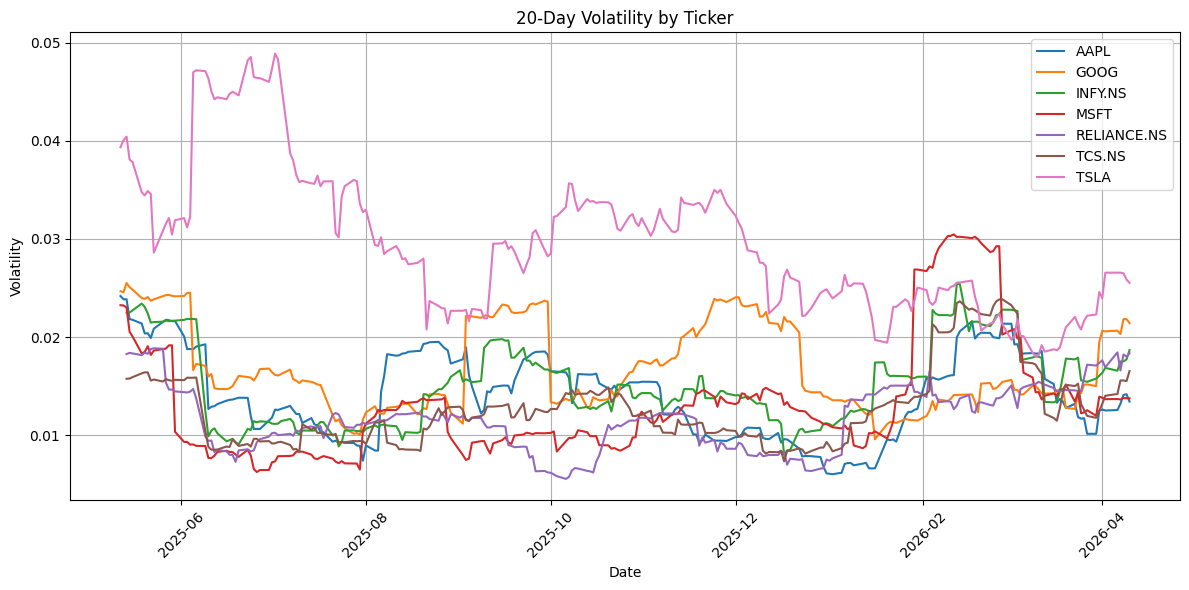

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"])

plt.figure(figsize=(12,6))

for ticker in df["Ticker"].unique():
    stock_df = df[df["Ticker"] == ticker].copy()
    stock_df["Return"] = stock_df["Close"].pct_change()
    stock_df["Volatility"] = stock_df["Return"].rolling(20).std()
    
    plt.plot(stock_df["Date"], stock_df["Volatility"], label=ticker)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.title("20-Day Volatility by Ticker")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

         Ticker Quarter_4M        Close      Volume  Price_Range    Return
0          AAPL    2025-Q1   202.430000   718068400     6.186154  0.006026
1          AAPL    2025-Q2   209.646310  4594152200     4.108810  0.001203
2          AAPL    2025-Q3   261.652000  4164785600     4.659765  0.001955
3          AAPL    2026-Q1   259.897500  3192214600     5.653382 -0.000497
4          GOOG    2025-Q1   157.959231   266998900     4.157692 -0.041041
5          GOOG    2025-Q2   181.732024  2168996600     4.150000  0.003526
6          GOOG    2025-Q3   275.373765  1982740700     6.608471  0.004743
7          GOOG    2026-Q1   313.111765  1477512600     7.883824  0.000232
8       INFY.NS    2025-Q1  1412.210833   122309737    35.546667 -0.032840
9       INFY.NS    2025-Q2  1524.312738   622415011    27.742262  0.000032
10      INFY.NS    2025-Q3  1519.228690   685602961    24.698095  0.001402
11      INFY.NS    2026-Q1  1435.670149   801563475    35.131343 -0.003143
12         MSFT    2025-Q

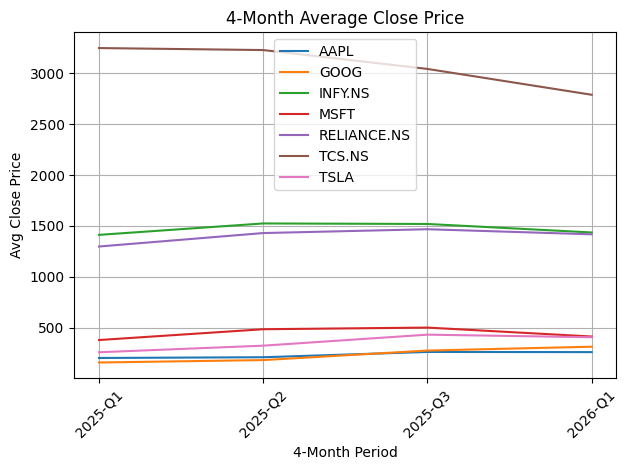

In [203]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# 4-month bucket (1-4, 5-8, 9-12)
df["Quarter_4M"] = ((df["Month"] - 1) // 4) + 1

df["Quarter_4M"] = df["Year"].astype(str) + "-Q" + df["Quarter_4M"].astype(str)

quarter_data = df.groupby(["Ticker", "Quarter_4M"]).agg({
    "Close": "mean",
    "Volume": "sum",
    "Price_Range": "mean",
    "Return": "mean"
}).reset_index()

print(quarter_data)


for ticker in df["Ticker"].unique():
    temp = quarter_data[quarter_data["Ticker"] == ticker]
    
    plt.plot(temp["Quarter_4M"].astype(str), temp["Close"], label=ticker)

plt.title("4-Month Average Close Price")
plt.xlabel("4-Month Period")
plt.ylabel("Avg Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

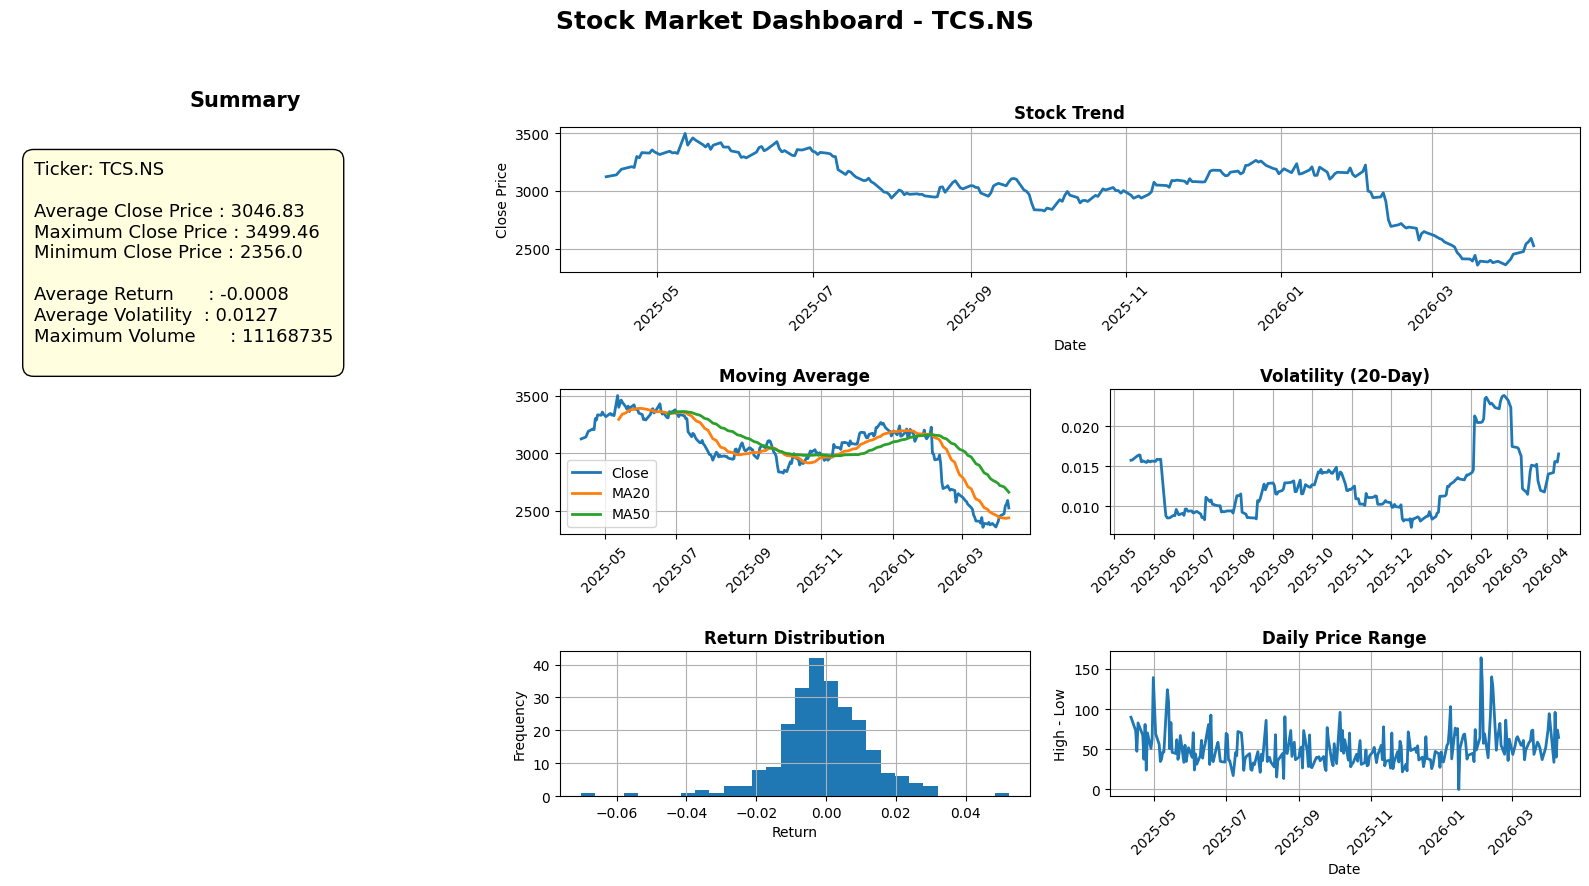

In [ ]:

# stock filter
stock_df = df[df["Ticker"] == "TCS.NS"].copy()
stock_df = stock_df.sort_values("Date")

# calculations
stock_df["Return"] = stock_df["Close"].pct_change()
stock_df["MA20"] = stock_df["Close"].rolling(20).mean()
stock_df["MA50"] = stock_df["Close"].rolling(50).mean()
stock_df["Volatility"] = stock_df["Return"].rolling(20).std()
stock_df["Price_Range"] = stock_df["High"] - stock_df["Low"]

# summary values
avg_close = round(stock_df["Close"].mean(), 2)
max_close = round(stock_df["Close"].max(), 2)
min_close = round(stock_df["Close"].min(), 2)
avg_return = round(stock_df["Return"].mean(), 4)
avg_volatility = round(stock_df["Volatility"].mean(), 4)
max_volume = int(stock_df["Volume"].max())

# dashboard
fig = plt.figure(figsize=(16, 9))
fig.suptitle("Stock Market Dashboard - TCS.NS", fontsize=18, fontweight="bold")

# 3 rows, 3 cols
# left side summary pura vertical lega
ax1 = plt.subplot2grid((3, 3), (0, 0), rowspan=3)
ax2 = plt.subplot2grid((3, 3), (0, 1), colspan=2)
ax3 = plt.subplot2grid((3, 3), (1, 1))
ax4 = plt.subplot2grid((3, 3), (1, 2))
ax5 = plt.subplot2grid((3, 3), (2, 1))
ax6 = plt.subplot2grid((3, 3), (2, 2))

# ---------------- LEFT SUMMARY ----------------
ax1.axis("off")
ax1.set_title("Summary", fontsize=15, fontweight="bold", pad=15)

summary_text = (
    f"Ticker: TCS.NS\n\n"
    f"Average Close Price : {avg_close}\n"
    f"Maximum Close Price : {max_close}\n"
    f"Minimum Close Price : {min_close}\n\n"
    f"Average Return      : {avg_return}\n"
    f"Average Volatility  : {avg_volatility}\n"
    f"Maximum Volume      : {max_volume}\n"
)

ax1.text(
    0.05, 0.95, summary_text,
    transform=ax1.transAxes,
    fontsize=13,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="lightyellow", edgecolor="black")
)

# TREND
ax2.plot(stock_df["Date"], stock_df["Close"], linewidth=2)
ax2.set_title("Stock Trend", fontweight="bold")
ax2.set_xlabel("Date")
ax2.set_ylabel("Close Price")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(True)

#  MOVING AVERAGE
ax3.plot(stock_df["Date"], stock_df["Close"], label="Close", linewidth=2)
ax3.plot(stock_df["Date"], stock_df["MA20"], label="MA20", linewidth=2)
ax3.plot(stock_df["Date"], stock_df["MA50"], label="MA50", linewidth=2)
ax3.set_title("Moving Average", fontweight="bold")
ax3.tick_params(axis="x", rotation=45)
ax3.legend()
ax3.grid(True)

#  VOLATILITY 
ax4.plot(stock_df["Date"], stock_df["Volatility"], linewidth=2)
ax4.set_title("Volatility (20-Day)", fontweight="bold")
ax4.tick_params(axis="x", rotation=45)
ax4.grid(True)

#  RETURN DISTRIBUTION 
ax5.hist(stock_df["Return"].dropna(), bins=30)
ax5.set_title("Return Distribution", fontweight="bold")
ax5.set_xlabel("Return")
ax5.set_ylabel("Frequency")
ax5.grid(True)

#  PRICE RANGE 
ax6.plot(stock_df["Date"], stock_df["Price_Range"], linewidth=2)
ax6.set_title("Daily Price Range", fontweight="bold")
ax6.set_xlabel("Date")
ax6.set_ylabel("High - Low")
ax6.tick_params(axis="x", rotation=45)
ax6.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()